In [1]:
import os

# Define o nome da pasta principal
nome_projeto = "Analise_Pegada_Carbono"

# Define as subpastas em português
subpastas = [
    "dados/brutos",
    "dados/processados",
    "notebooks",
    "docs",
    "scripts"
]

# Cria a estrutura
if not os.path.exists(nome_projeto):
    os.makedirs(nome_projeto)
    print(f"✅ Pasta raiz '{nome_projeto}' criada.")

for pasta in subpastas:
    caminho = os.path.join(nome_projeto, pasta)
    if not os.path.exists(caminho):
        os.makedirs(caminho)
        print(f"  + Subpasta '{pasta}' criada.")

print("\n🚀 Estrutura pronta para começar o projeto!")

✅ Pasta raiz 'Analise_Pegada_Carbono' criada.
  + Subpasta 'dados/brutos' criada.
  + Subpasta 'dados/processados' criada.
  + Subpasta 'notebooks' criada.
  + Subpasta 'docs' criada.
  + Subpasta 'scripts' criada.

🚀 Estrutura pronta para começar o projeto!


In [2]:
import pandas as pd

# 1. Definir o caminho exato onde o arquivo está
caminho_dados = '/content/Analise_Pegada_Carbono/dados/brutos/consumo_energia_emissoes_br.csv'

# 2. Carregar o dataset usando o pandas
df = pd.read_csv(caminho_dados)

# 3. Inspeção Visual
print("✅ Dataset carregado com sucesso!")
print(f"O arquivo contém {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

print("--- Primeiras 5 linhas do Dataset ---")
display(df.head())

print("\n--- Resumo Técnico (Tipos de Dados e Nulos) ---")
df.info()

print("\n--- Estatísticas Descritivas Básicas ---")
display(df.describe())

✅ Dataset carregado com sucesso!
O arquivo contém 100000 linhas e 9 colunas.

--- Primeiras 5 linhas do Dataset ---


,company_id,date,state,usage_type,company_size,fuel_type,energy_kwh,energy_source,co2_emission
0,C400203,2025-10-25T00:00:00,BA,industrial,small,eletrico,"41636,27532",wind,"416,3627532"
1,C121611,2025-07-25T00:00:00,SP,industrial,small,eletrico,"173135,7297",thermal,"103881,4378"
2,C963481,2025-10-28T00:00:00,SP,industrial,large,eletrico,"65674,93012",hydro,"1313,498602"
3,C145272,2025-02-23T00:00:00,SP,comercial,medium,eletrico,"1541,159336",hydro,"30,82318672"
4,C240228,2025-09-26T00:00:00,DF,residencial,small,eletrico,"104,9449192",hydro,"2,098898384"



--- Resumo Técnico (Tipos de Dados e Nulos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   company_id     100000 non-null  object
 1   date           100000 non-null  object
 2   state          100000 non-null  object
 3   usage_type     100000 non-null  object
 4   company_size   100000 non-null  object
 5   fuel_type      100000 non-null  object
 6   energy_kwh     100000 non-null  object
 7   energy_source  100000 non-null  object
 8   co2_emission   100000 non-null  object
dtypes: object(9)
memory usage: 6.9+ MB

--- Estatísticas Descritivas Básicas ---


,company_id,date,state,usage_type,company_size,fuel_type,energy_kwh,energy_source,co2_emission
count,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,94748,336,27,5,3,1,99997,5,99998
top,C295462,2025-12-28T00:00:00,SP,industrial,small,eletrico,"367659,7924",hydro,"7353,195849"
freq,4,350,28576,39023,52494,100000,4,51758,2


In [3]:
# 1. Converter a coluna de data para o formato correto de data
df['date'] = pd.to_datetime(df['date'])

# 2. Converter colunas numéricas (forçando erro para NaN caso haja lixo no texto e depois tratando)
# Se houver vírgulas no lugar de pontos, o pandas pode se confundir, por isso usamos o replace
cols_numericas = ['energy_kwh', 'co2_emission']

for col in cols_numericas:
    # Caso os números venham com vírgula como separador decimal:
    df[col] = df[col].astype(str).str.replace(',', '.')
    # Converte para numérico
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Verificar se a conversão deu certo
print("✅ Conversão concluída!")
print("\n--- Novos Tipos de Dados ---")
print(df.dtypes)

print("\n--- Agora as estatísticas matemáticas funcionam! ---")
display(df.describe())

✅ Conversão concluída!

--- Novos Tipos de Dados ---
company_id               object
date             datetime64[ns]
state                    object
usage_type               object
company_size             object
fuel_type                object
energy_kwh              float64
energy_source            object
co2_emission            float64
dtype: object

--- Agora as estatísticas matemáticas funcionam! ---


,date,energy_kwh,co2_emission
count,100000,100000.000000,100000.000000
mean,2025-06-29 20:25:02.208000256,18008.454847,2708.297297
min,2025-01-01 00:00:00,50.067184,0.649168
25%,2025-03-28 00:00:00,258.217932,11.990817
50%,2025-06-28 00:00:00,2482.103857,121.643196
75%,2025-10-01 00:00:00,29515.466135,774.199552
max,2025-12-28 00:00:00,367659.792400,220595.875500
std,NaN,27647.014992,9096.628021


📊 RELATÓRIO EXECUTIVO DE EMISSÕES DE CO2

[1] EMISSÕES TOTAIS POR SETOR (kg CO2):
 - Industrial: 257,836,141.42 kg
 - Outros: 7,650,076.13 kg
 - Comercial: 3,984,908.26 kg
 - Residencial: 777,209.08 kg
 - Rural: 581,394.76 kg

[2] TOP 5 ESTADOS COM MAIORES EMISSÕES:
 - SP: 77,480,095.87 kg
 - MG: 46,524,549.13 kg
 - PR: 19,968,418.33 kg
 - PA: 16,344,117.11 kg
 - RS: 15,797,722.92 kg

[3] INTENSIDADE DE CARBONO POR FONTE (kg CO2/kWh):
 - Thermal: 0.6000 kg CO2/kWh
 - Hydro: 0.0200 kg CO2/kWh
 - Solar: 0.0200 kg CO2/kWh
 - Nuclear: 0.0100 kg CO2/kWh
 - Wind: 0.0100 kg CO2/kWh



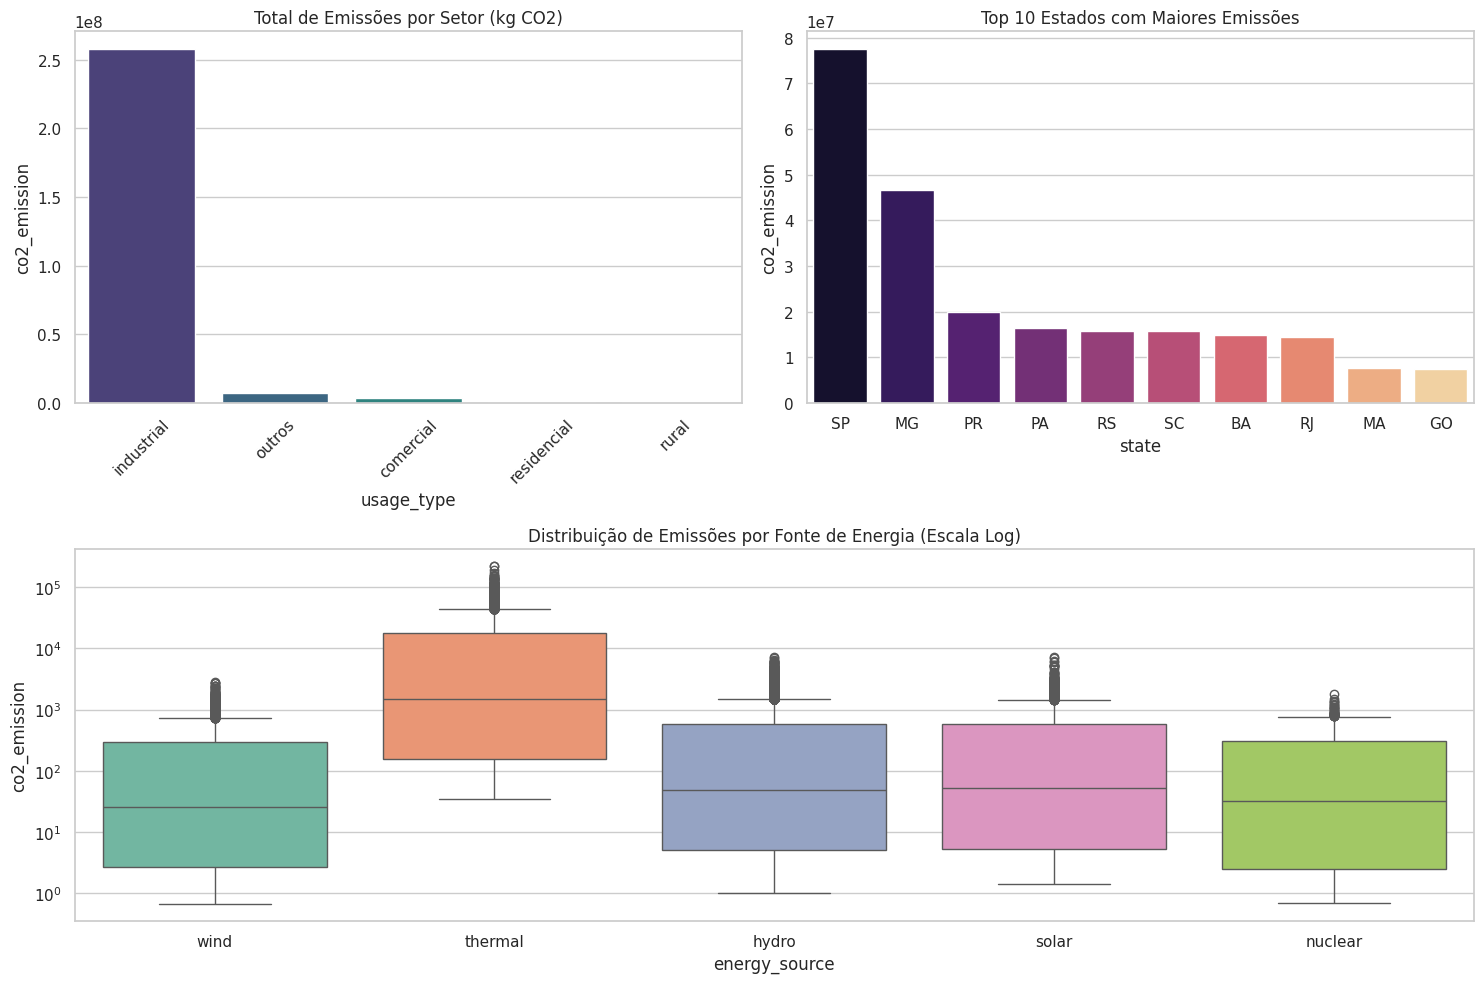

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Silencia avisos genéricos
warnings.filterwarnings('ignore', category=FutureWarning)

# --- 1. PREPARAÇÃO DOS DADOS PARA O RELATÓRIO ---
# Emissões por Setor
setor_emissao = df.groupby('usage_type')['co2_emission'].sum().sort_values(ascending=False).reset_index()

# Emissões por Estado (Top 5 para o console)
estado_emissao_full = df.groupby('state')['co2_emission'].sum().sort_values(ascending=False).reset_index()
top_estados = estado_emissao_full.head(10)

# Intensidade de Carbono
resumo_fontes = df.groupby('energy_source')[['co2_emission', 'energy_kwh']].sum()
intensidade = (resumo_fontes['co2_emission'] / resumo_fontes['energy_kwh']).sort_values(ascending=False)

# --- 2. RELATÓRIO POR ESCRITO NO CONSOLE ---
print("="*50)
print("📊 RELATÓRIO EXECUTIVO DE EMISSÕES DE CO2")
print("="*50)

print("\n[1] EMISSÕES TOTAIS POR SETOR (kg CO2):")
for index, row in setor_emissao.iterrows():
    print(f" - {row['usage_type'].capitalize()}: {row['co2_emission']:,.2f} kg")

print("\n[2] TOP 5 ESTADOS COM MAIORES EMISSÕES:")
for index, row in estado_emissao_full.head(5).iterrows():
    print(f" - {row['state']}: {row['co2_emission']:,.2f} kg")

print("\n[3] INTENSIDADE DE CARBONO POR FONTE (kg CO2/kWh):")
for fonte, valor in intensidade.items():
    print(f" - {fonte.capitalize()}: {valor:.4f} kg CO2/kWh")

print("\n" + "="*50)

# --- 3. PARTE VISUAL (GRÁFICOS) ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# Gráfico de Barras: Setor
plt.subplot(2, 2, 1)
sns.barplot(data=setor_emissao, x='usage_type', y='co2_emission', hue='usage_type', palette='viridis', legend=False)
plt.title('Total de Emissões por Setor (kg CO2)')
plt.xticks(rotation=45)

# Gráfico de Barras: Estado
plt.subplot(2, 2, 2)
sns.barplot(data=top_estados, x='state', y='co2_emission', hue='state', palette='magma', legend=False)
plt.title('Top 10 Estados com Maiores Emissões')

# Boxplot: Fonte de Energia
plt.subplot(2, 1, 2)
sns.boxplot(data=df, x='energy_source', y='co2_emission', hue='energy_source', palette='Set2', legend=False)
plt.yscale('log')
plt.title('Distribuição de Emissões por Fonte de Energia (Escala Log)')

plt.tight_layout()
plt.show()

✅ NOVA VARIÁVEL: IMPACTO AMBIENTAL
 - Baixo Impacto: 33000 registros (33.0%)
 - Médio Impacto: 33000 registros (33.0%)
 - Alto Impacto: 34000 registros (34.0%)

💾 Arquivo salvo com sucesso em:
/content/Analise_Pegada_Carbono/dados/processados/dados_energia_limpos.csv


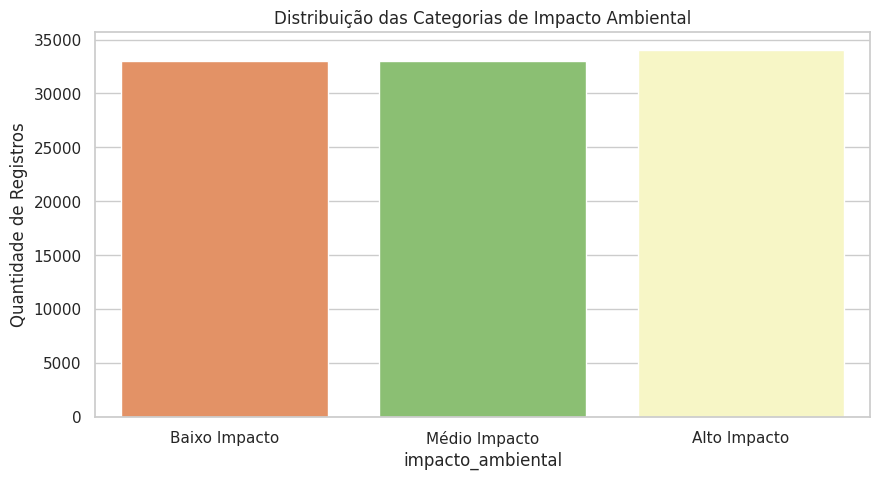

In [7]:
import numpy as np

# 1. Criar a classificação baseada nos percentis das emissões
# Vamos dividir em 3 grupos iguais (33% cada)
limites = df['co2_emission'].quantile([0.33, 0.66]).values

def categorizar_impacto(valor):
    if valor <= limites[0]:
        return 'Baixo Impacto'
    elif valor <= limites[1]:
        return 'Médio Impacto'
    else:
        return 'Alto Impacto'

# Aplicar a função
df['impacto_ambiental'] = df['co2_emission'].apply(categorizar_impacto)

# 2. RELATÓRIO TEXTUAL DA NOVA COLUNA
print("="*50)
print("✅ NOVA VARIÁVEL: IMPACTO AMBIENTAL")
print("="*50)

contagem = df['impacto_ambiental'].value_counts()
porcentagem = df['impacto_ambiental'].value_counts(normalize=True) * 100

for cat in ['Baixo Impacto', 'Médio Impacto', 'Alto Impacto']:
    print(f" - {cat}: {contagem[cat]} registros ({porcentagem[cat]:.1f}%)")

print("\n" + "="*50)

# 3. SALVAR O DATASET PROCESSADO
caminho_processado = '/content/Analise_Pegada_Carbono/dados/processados/dados_energia_limpos.csv'
df.to_csv(caminho_processado, index=False)
print(f"💾 Arquivo salvo com sucesso em:\n{caminho_processado}")

# 4. VISUALIZAÇÃO DA DISTRIBUIÇÃO
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='impacto_ambiental', order=['Baixo Impacto', 'Médio Impacto', 'Alto Impacto'],
              hue='impacto_ambiental', palette='RdYlGn_r', legend=False)
plt.title('Distribuição das Categorias de Impacto Ambiental')
plt.ylabel('Quantidade de Registros')
plt.show()

🤖 RELATÓRIO DO MODELO PREDITIVO
               precision    recall  f1-score   support

 Alto Impacto       0.90      0.75      0.82      6774
Baixo Impacto       0.78      0.95      0.85      6644
Médio Impacto       0.72      0.68      0.70      6582

     accuracy                           0.79     20000
    macro avg       0.80      0.79      0.79     20000
 weighted avg       0.80      0.79      0.79     20000



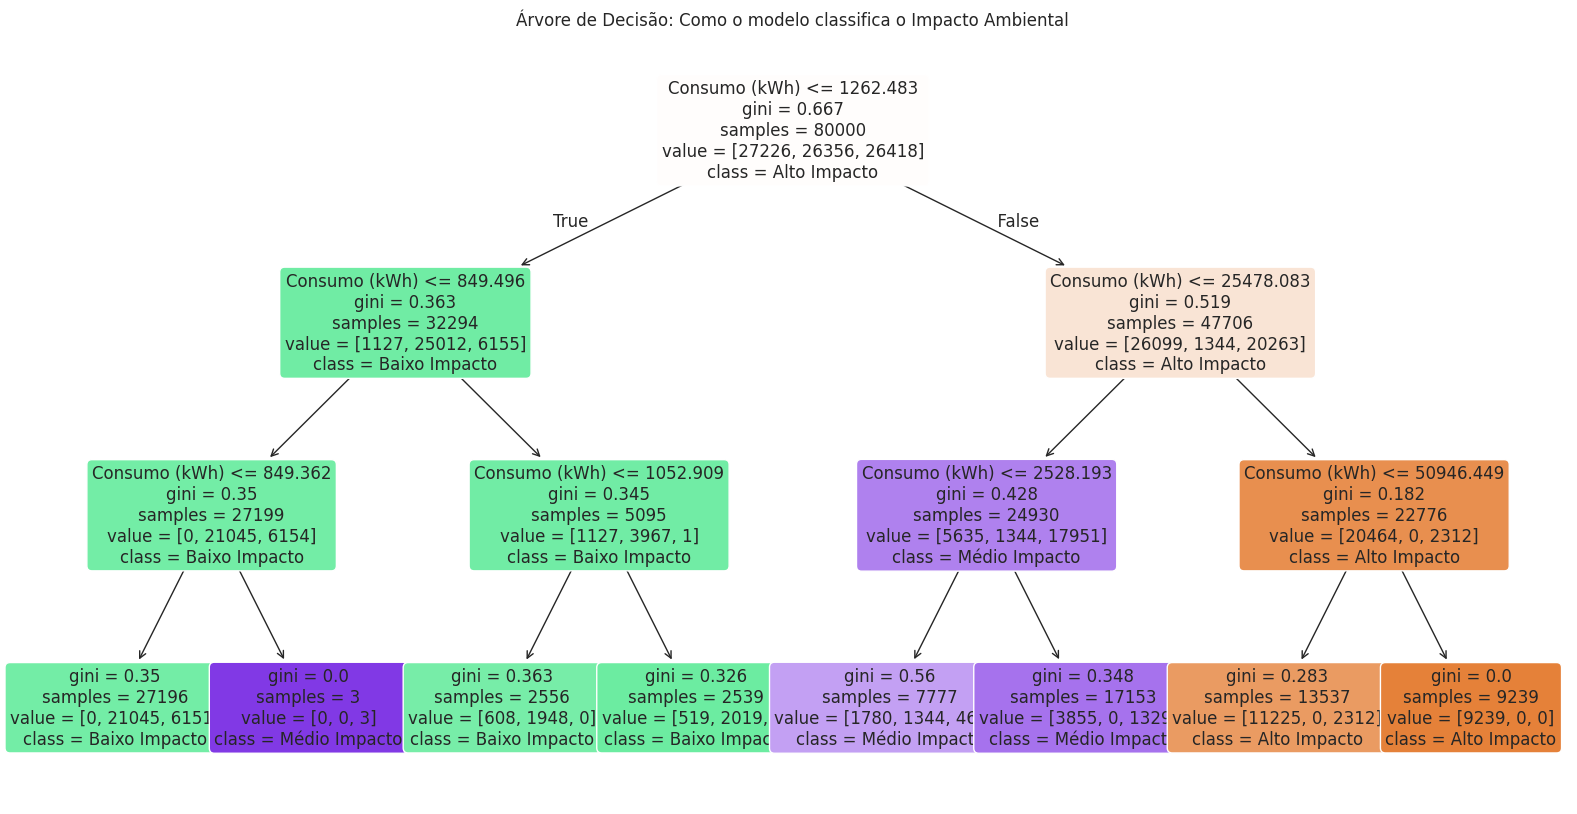

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

# 1. PREPARAÇÃO DOS DADOS
# Vamos usar o consumo e o setor para prever o impacto ambiental
# Precisamos transformar o texto (setor) em números para o modelo entender
df_modelo = df.copy()
df_modelo['usage_type_encoded'] = df_modelo['usage_type'].astype('category').cat.codes

X = df_modelo[['energy_kwh', 'usage_type_encoded']]
y = df_modelo['impacto_ambiental']

# Dividir em Treino (80%) e Teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. TREINAMENTO DO MODELO
# Limitamos a profundidade (max_depth) para a árvore não ficar gigante e ser legível
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_treino, y_treino)

# 3. RELATÓRIO DE DESEMPENHO NO CONSOLE
print("="*50)
print("🤖 RELATÓRIO DO MODELO PREDITIVO")
print("="*50)
previsoes = modelo.predict(X_teste)
print(classification_report(y_teste, previsoes))

# 4. VISUALIZAÇÃO DA ÁRVORE (O "MAPA" DA DECISÃO)
plt.figure(figsize=(20,10))
plot_tree(modelo, feature_names=['Consumo (kWh)', 'Tipo de Uso'],
          class_names=modelo.classes_, filled=True, rounded=True, fontsize=12)
plt.title("Árvore de Decisão: Como o modelo classifica o Impacto Ambiental")
plt.show()